# Binary Classification: Zero vs. Any Damage
This model is the first tier of the hierarchical approach. Its goal is to maximize the recall for damage events while keeping a high precision for zero-damage cases.

In [1]:
import pandas as pd
import numpy as np
import optuna
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# ---------------------------------------------------------
# 1. Load the Datasets & Transform to Binary
# ---------------------------------------------------------
print("Loading datasets...")

DATA_PATH = '../processed_datasets/'
X_TRAIN_PATH = DATA_PATH + 'X_train_catboost.parquet'
X_VAL_PATH = DATA_PATH + 'X_val_catboost.parquet'
X_TEST_PATH = DATA_PATH + 'X_test_catboost.parquet'

Y_TRAIN_PATH = DATA_PATH + 'y_train.csv'
Y_VAL_PATH = DATA_PATH + 'y_val.csv'
Y_TEST_PATH = DATA_PATH + 'y_test.csv'

X_train = pd.read_parquet(X_TRAIN_PATH, engine="fastparquet")
X_val = pd.read_parquet(X_VAL_PATH, engine="fastparquet")
X_test = pd.read_parquet(X_TEST_PATH, engine="fastparquet")

y_train_raw = pd.read_csv(Y_TRAIN_PATH).squeeze()
y_val_raw = pd.read_csv(Y_VAL_PATH).squeeze()
y_test_raw = pd.read_csv(Y_TEST_PATH).squeeze()

# TRANSFORM TO BINARY: 0 = No Damage, 1 = Any Damage (1-4)
y_train = (y_train_raw > 0).astype(int)
y_val = (y_val_raw > 0).astype(int)
y_test = (y_test_raw > 0).astype(int)

print(f"Target distribution (Train):\n{y_train.value_counts(normalize=True)}")
print(f"Train shapes: X={X_train.shape}, y={y_train.shape}")

categorical_features = X_train.select_dtypes(include=['object', 'category', 'string']).columns.tolist()
categorical_features.extend(['DAY_OF_WEEK'])
print(f"Detected {len(categorical_features)} categorical features.")

Loading datasets...
Target distribution (Train):
DAMAGE_CLASS
0    0.615161
1    0.384839
Name: proportion, dtype: float64
Train shapes: X=(876565, 32), y=(876565,)
Detected 11 categorical features.


In [3]:
# ---------------------------------------------------------
# 2. Define the Optuna Objective Function
# ---------------------------------------------------------
def objective(trial):
    params = {
        "iterations": 2000,
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.1, log=True),
        "depth": trial.suggest_int("depth", 4, 10),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1, 10),
        "random_strength": trial.suggest_float("random_strength", 1, 10),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0, 1),
        "grow_policy": trial.suggest_categorical("grow_policy", ["SymmetricTree", "Depthwise", "Lossguide"]),
        "auto_class_weights": "Balanced",
        "random_seed": 42,
        "verbose": False,
        "task_type": "GPU",
        "eval_metric": "Logloss"
    }
    
    model = CatBoostClassifier(**params)

    model.fit(
        X_train, 
        y_train,
        cat_features=categorical_features,
        eval_set=[(X_val, y_val)],
        early_stopping_rounds=100, 
        use_best_model=True
    )

    preds_class = np.squeeze(model.predict(X_val))
    # We optimize for Macro F1 to ensure both classes are weighted equally in the gatekeeper model
    score = f1_score(y_val, preds_class, average='macro')
    
    return score

In [4]:
# ---------------------------------------------------------
# 3. Run the Optuna Study
# ---------------------------------------------------------
print("Starting Optuna hyperparameter tuning for Binary Gatekeeper...")

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)

print("\n--- Optimization Finished ---")
print(f"Best Macro F1: {study.best_value:.4f}")
print("Best Parameters:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

[I 2026-06-09 18:18:21,846] A new study created in memory with name: no-name-7bf0c2c8-bcdc-4a70-b085-9f638f3810f8


Starting Optuna hyperparameter tuning for Binary Gatekeeper...


[I 2026-06-09 18:28:20,592] Trial 0 finished with value: 0.861363033165336 and parameters: {'learning_rate': 0.012163529473993196, 'depth': 6, 'l2_leaf_reg': 9.613521148945718, 'random_strength': 6.436127245298395, 'bagging_temperature': 0.811206619573193, 'grow_policy': 'SymmetricTree'}. Best is trial 0 with value: 0.861363033165336.
[I 2026-06-09 18:29:48,948] Trial 1 finished with value: 0.8651641191828302 and parameters: {'learning_rate': 0.020232891682549298, 'depth': 10, 'l2_leaf_reg': 9.384880671746483, 'random_strength': 1.9773691001221039, 'bagging_temperature': 0.48620238333852195, 'grow_policy': 'Lossguide'}. Best is trial 1 with value: 0.8651641191828302.
[I 2026-06-09 18:31:02,726] Trial 2 finished with value: 0.85241067162742 and parameters: {'learning_rate': 0.04216119487829322, 'depth': 4, 'l2_leaf_reg': 3.6078739610136434, 'random_strength': 8.545800502316645, 'bagging_temperature': 0.44159982732368475, 'grow_policy': 'Depthwise'}. Best is trial 1 with value: 0.8651641


--- Optimization Finished ---
Best Macro F1: 0.8696
Best Parameters:
  learning_rate: 0.0026065724304786086
  depth: 10
  l2_leaf_reg: 4.0907346582444974
  random_strength: 2.0573498869945923
  bagging_temperature: 0.36388998800275657
  grow_policy: Depthwise


In [ ]:
# ---------------------------------------------------------
# 4. Train Final Model & Evaluate on Test Set
# ---------------------------------------------------------
print("\nTraining final binary model...")

final_params = study.best_params.copy()
final_params.update({
    "iterations": 2000,
    "auto_class_weights": "Balanced",
    "random_seed": 42,
    "verbose": False,
    "task_type": "GPU"
})

final_model = CatBoostClassifier(**final_params)

final_model.fit(
    X_train, 
    y_train,
    cat_features=categorical_features,
    eval_set=[(X_val, y_val)],
    early_stopping_rounds=100,
    use_best_model=True
)

y_pred = final_model.predict(X_test)
print(f"Final Test Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Training final binary model...
Final Test Accuracy: 0.8842

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.92      0.92     86950
           1       0.76      0.78      0.77     29048

    accuracy                           0.88    115998
   macro avg       0.84      0.85      0.85    115998
weighted avg       0.89      0.88      0.88    115998

Confusion Matrix:
[[79788  7162]
 [ 6269 22779]]


In [6]:
final_model.save_model("catboost_binary.cbm")

### Feature Importance

In [2]:
model = CatBoostClassifier().load_model("catboost_binary.cbm")

/tmp/ipykernel_8075/475268667.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Importance', y='Feature', palette='mako')


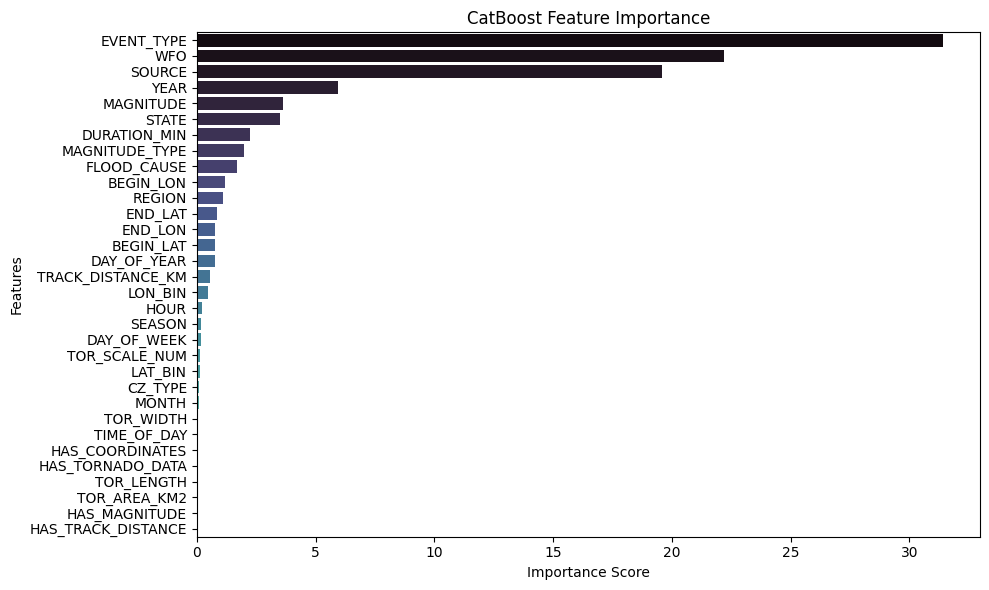

In [3]:
importances = model.get_feature_importance()
feature_names = model.feature_names_

# Pack them into a DataFrame for clean sorting and plotting
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Visualize the results
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='mako')
plt.title('CatBoost Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()